In [2]:
import numpy as np
import os
from scipy.stats import expon, uniform, beta
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from time import time
from joblib import cpu_count
import networkx as nx
import pickle

from InfluenceDiffusion.estimation_models.OptimEstimation import GLTWeightEstimator
from InfluenceDiffusion.weight_samplers import make_random_weights_with_indeg_constraint
from InfluenceDiffusion.influence_models import LTM
from InfluenceDiffusion.Graph import Graph
from InfluenceDiffusion.Trace import Trace, Traces

os.chdir("/Users/amkagan/Desktop/Archive/gltm_experiments")


from utils.trace_utils import make_report_traces
from utils.utils import RMAE, make_name_from_dict, plot_distribution

print("CPUs available", cpu_count())

CPUs available 8


In [3]:
def compute_new_parent_appearence_times_in_trace(trace: Trace):
    informative_vs = trace.get_all_failed_and_activated_vertices_no_seed()
    activ_time_dict = trace.get_activation_time_dict()
    v_2_new_parent_times = {}
    for v in informative_vs:
        
        v_time = activ_time_dict[v] if v in activ_time_dict else np.inf
        active_parents = set(trace.graph.get_parents(v)).intersection(activ_time_dict)
        new_parent_appearence_times = set([activ_time_dict[u] for u in active_parents if activ_time_dict[u] < v_time])
        v_2_new_parent_times[v] = new_parent_appearence_times
    return v_2_new_parent_times

def compute_vertex_sample_size(traces: Traces):
    v_2_total_appearences = {v: 0 for v in traces[0].graph.get_sinks()}
    v_2_num_informative_traces = {v: 0 for v in traces[0].graph.get_sinks()}
    for trace in traces:
        v_2_new_parent_times = compute_new_parent_appearence_times_in_trace(trace)
        for v, new_parent_times in v_2_new_parent_times.items():
            v_2_total_appearences[v] += len(new_parent_times)
            v_2_num_informative_traces[v] += 1
    return v_2_total_appearences, v_2_num_informative_traces


def connected_boxplots(data, labels=None, ax=None, show_points=True, ylab=None, xlab=None,
                      fontsize=12, rotation=0):
    """
    data: dict of dicts, e.g.
          {
              "A": {"v1": 3, "v2": 7, "v3": 5},
              "B": {"v1": 4, "v2": 6, "v3": 8},
              "C": {"v1": 2, "v2": 9, "v3": 6},
          }

          Outer keys become x-axis labels by default.
          Inner keys identify matched observations to connect across boxes.
    """

    if not data:
        raise ValueError("data must be non-empty")

    outer_keys = list(data.keys())
    inner_keys = list(data[outer_keys[0]].keys())

    if any(set(data[k].keys()) != set(inner_keys) for k in outer_keys):
        raise ValueError("All inner dictionaries must have the same keys")

    if labels is None:
        labels = outer_keys

    if len(labels) != len(outer_keys):
        raise ValueError("labels must have the same length as data")

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    x = np.arange(len(outer_keys))

    # One boxplot per outer key
    box_data = [
        [data[outer_key][inner_key] for inner_key in inner_keys]
        for outer_key in outer_keys
    ]

    ax.boxplot(
        box_data,
        positions=x,
        widths=0.5,
        patch_artist=True,
        showfliers=False,
    )

    # Connect values for the same inner key across boxplots
    for inner_key in inner_keys:
        y = [data[outer_key][inner_key] for outer_key in outer_keys]
        ax.plot(x, y, marker="o", alpha=0.15, color="grey")

    if show_points:
        for i, outer_key in enumerate(outer_keys):
            y = [data[outer_key][inner_key] for inner_key in inner_keys]
            ax.scatter([x[i]] * len(y), y, zorder=3, alpha=0.5, color="darkblue")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=fontsize-2, rotation=rotation)
    ax.set_ylabel(ylab, fontsize=fontsize)
    ax.set_xlabel(xlab, fontsize=fontsize)
    ax.grid(axis="y", alpha=0.3)

    return ax


In [5]:
n_nodes = 100
init_k = 10
rewire_p = 0.2
n_traces = 2000
test_ratio = 0.25

random_state = 1
max_seed_size = 10
seed_size_range = list(range(1, max_seed_size + 1))

g = nx.watts_strogatz_graph(n_nodes, k=init_k, p=rewire_p, seed=random_state)
g = Graph(g.edges)

weights = make_random_weights_with_indeg_constraint(g, indeg_ub=1, random_state=random_state)                       
g.set_weights(weights)

In [6]:
ab_pairs = [(2, 1), (1, 1),  (1, 2), (1, 3), (1, 4), (1, 5)]

In [12]:
from utils.utils import RMAE

seed_size_range = range(1, 6)
n_traces = 1000

ab_2_Nv_over_vertices = {}

ab_2_avg_Tv_over_vertices = {}
ab_2_Iv_over_vertices = {}
ab_2_Iv_div_N_over_vertices = {}
avg_trace_lens = []
ab_2_parent_weight_error_over_traces = {}

for ab_pair in ab_pairs:
    threshold_generator = beta(*ab_pair)
    gltm = LTM(g, threshold_generator=threshold_generator, random_state=random_seed)
    traces = gltm.sample_traces(n_traces, seed_size_range=seed_size_range)
    vertex_2_Nv, vertex_2_Iv = compute_vertex_sample_size(traces)
    ab_2_avg_Tv_over_vertices[ab_pair] = {v: vertex_2_Nv[v] / vertex_2_Iv[v] for v in vertex_2_Nv}
    ab_2_Iv_over_vertices[ab_pair] = vertex_2_Iv
    ab_2_Iv_div_N_over_vertices[ab_pair] = {v: vertex_2_Iv[v] / len(traces) for v in vertex_2_Iv}
    ab_2_Nv_over_vertices[ab_pair] = vertex_2_Nv
    avg_trace_lens.append(np.mean([trace.length for trace in traces]))

    glt_estimator = GLTWeightEstimator(g, vertex_2_distrib=threshold_generator, n_jobs=8)
    weights_pred = glt_estimator.fit(traces)
    ab_2_parent_weight_error_over_traces[ab_pair] = {v: RMAE(weights[g.get_parents_mask(v)], weights_pred[g.get_parents_mask(v)])
                                                     for v in g.get_sinks()}

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

def plot_sorted_dict_relationship(
    data_x,
    data_y,
    labels=None,
    ax=None,
    ylab=None,
    xlab=None,
    fontsize=12,
    rotation=0,
    bin_x=False,
    show_errorbar=True,
):
    """
    Plot matched values from two dicts of dicts.

    data_x, data_y: dicts of dicts with the same outer and inner keys, e.g.
        data_x = {
            "A": {"v1": 3.1, "v2": 7.4, "v3": 3.8, "v4": 9.2},
            "B": {"v1": 4.5, "v2": 6.2, "v3": 4.1, "v4": 10.7},
        }

        data_y = {
            "A": {"v1": 10, "v2": 20, "v3": 14, "v4": 30},
            "B": {"v1": 8, "v2": 11, "v3": 10, "v4": 19},
        }

    For each outer key, e.g. "A":
      - Sort inner keys by data_x[outer_key][inner_key].
      - Use data_x values as x-values.
      - Use corresponding data_y values as y-values.
      - If bin_x=False, group identical x-values.
      - If bin_x=True, group x-values into bins [k, k + 1).
      - Plot mean y-value for each group.
      - Plot standard-error whiskers only if show_errorbar=True.

    Parameters
    ----------
    bin_x : bool
        If False, group by exact x-values.
        If True, group observations into integer bins [k, k + 1).

    show_errorbar : bool
        If True, plot standard error whiskers.
        If False, plot only the mean curve.
    """

    if not data_x:
        raise ValueError("data_x must be non-empty")

    outer_keys = list(data_x.keys())

    if labels is None:
        labels = outer_keys

    if len(labels) != len(outer_keys):
        raise ValueError("labels must have the same length as data_x")

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    for outer_key, label in zip(outer_keys, labels):
        inner_keys = list(data_x[outer_key].keys())

        inner_keys_sorted = sorted(
            inner_keys,
            key=lambda inner_key: data_x[outer_key][inner_key],
        )

        grouped_y = defaultdict(list)

        for inner_key in inner_keys_sorted:
            x_val = data_x[outer_key][inner_key]
            y_val = data_y[outer_key][inner_key]

            if bin_x:
                group_key = int(np.floor(x_val))  # bin [k, k + 1)
            else:
                group_key = x_val                 # exact x-value

            grouped_y[group_key].append(y_val)

        group_keys = sorted(grouped_y.keys())

        if bin_x:
            # Plot interval [k, k + 1) at midpoint k + 0.5
            x_vals = np.array([k + 0.5 for k in group_keys], dtype=float)
        else:
            x_vals = np.array(group_keys, dtype=float)

        y_means = []
        y_sems = []

        for group_key in group_keys:
            ys = np.array(grouped_y[group_key], dtype=float)
            y_means.append(np.mean(ys))

            if len(ys) > 1:
                y_sems.append(np.std(ys, ddof=1) / np.sqrt(len(ys)))
            else:
                y_sems.append(0.0)

        y_means = np.array(y_means)
        y_sems = np.array(y_sems)

        if show_errorbar:
            ax.errorbar(
                x_vals,
                y_means,
                yerr=y_sems,
                marker="o",
                capsize=3,
                label=label,
            )
        else:
            ax.plot(
                x_vals,
                y_means,
                marker="o",
                label=label,
            )

    ax.set_ylabel(ylab, fontsize=fontsize)
    ax.set_xlabel(xlab, fontsize=fontsize)

    ax.tick_params(axis="both", labelsize=fontsize - 2)
    ax.tick_params(axis="x", rotation=rotation)

    if bin_x:
        all_bins = sorted({
            int(np.floor(data_x[outer_key][inner_key]))
            for outer_key in outer_keys
            for inner_key in data_x[outer_key]
        })

        ax.set_xticks([k + 0.5 for k in all_bins])
        ax.set_xticklabels(
            [f"[{k}, {k + 1})" for k in all_bins],
            fontsize=fontsize - 2,
            rotation=rotation,
        )

    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=fontsize - 2)

    return ax

In [242]:
# for ab_pair in ab_pairs:
#     print(np.corrcoef(list(ab_2_avg_Tv_over_vertices[ab_pair].values()), 
#                       list(ab_2_parent_weight_error_over_traces[ab_pair].values())))

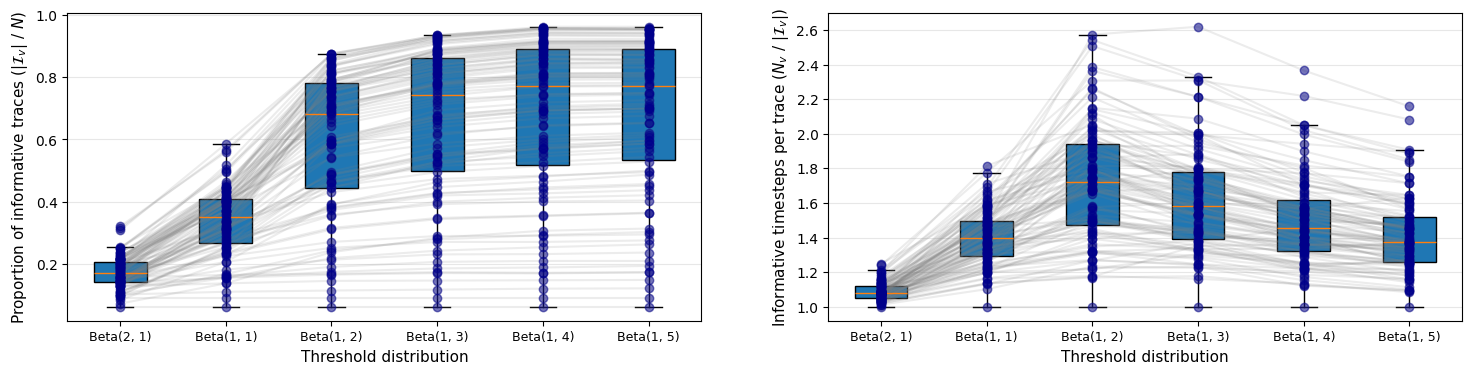

In [33]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))
rotation = 0

connected_boxplots(ab_2_Iv_div_N_over_vertices, labels=[f"Beta({a}, {b})" for a, b in ab_pairs], 
                   ax=axs[0], xlab=r"Threshold distribution", 
                   ylab="Proportion of informative traces ($|\mathcal{I}_v| \ / \ N$)", 
                   rotation=rotation, fontsize=11)
# axs[0].text(2, 0.1, "$\longrightarrow$" + " Nodes are easier to influence")

connected_boxplots(ab_2_avg_Tv_over_vertices, labels=[f"Beta({a}, {b})" for a, b in ab_pairs], 
                   ax=axs[1], 
                   xlab="Threshold distribution",
                   ylab="Informative timesteps per trace ($N_v \ / \ |\mathcal{I}_v|$)", 
                   rotation=rotation, fontsize=11)

# axs[1].plot(avg_trace_lens, marker="*", markersize=8, color="red", linestyle="--", zorder=10, label="Average trace length")
# axs[1].text(2, 0.5, "$\longrightarrow$" + " Nodes are easier to influence")
# axs[1].legend()


# plot_sorted_dict_relationship(ab_2_avg_Tv_over_vertices, ab_2_parent_weight_error_over_traces, 
#                               labels=[f"Beta({a}, {b})" for a, b in ab_pairs], 
#                                ax=axs[2], 
#                                xlab="Threshold distribution",
#                                ylab="Parent edge error " + r"$\|\hat{\theta}_v - \theta^*_v\|_2$", 
#                                rotation=rotation, fontsize=11, bin_x=True)


plt.show()
                        

In [221]:
# g = Graph([[0, 1], [0, 2], [1, 2]])
# trace = Trace(g, ({0}, {1}, {2}))
# compute_num_vertex_appearences_in_trace(trace)
# trace.gr


In [28]:
glt_estimator = GLTWeightEstimator(g, vertex_2_distrib=threshold_generator, n_jobs=8)
%time  weights_pred = glt_estimator.fit(traces)

CPU times: user 4.85 s, sys: 194 ms, total: 5.05 s
Wall time: 7.87 s


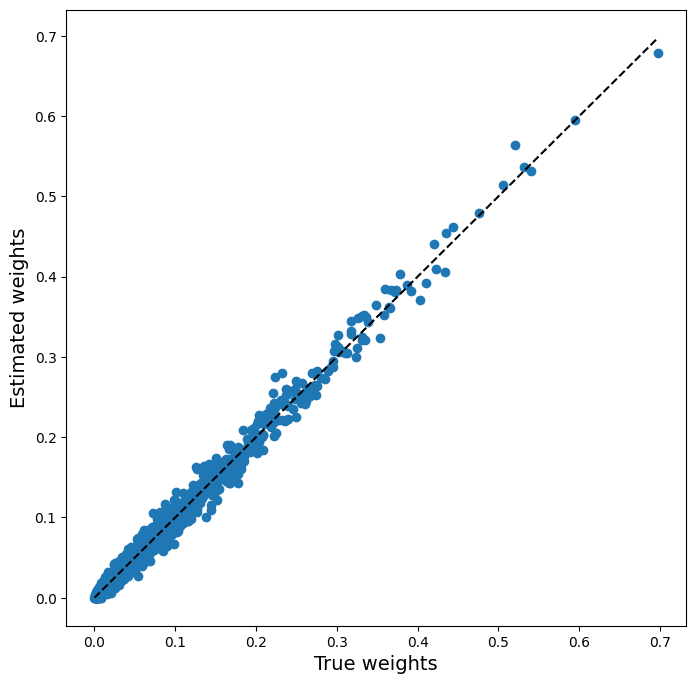

In [10]:
true_linsapce = np.linspace(0, max(weights), 100)
plt.figure(figsize=(8, 8))
plt.scatter(weights, weights_pred)
plt.plot(true_linsapce, true_linsapce, c="black", linestyle="dashed")
plt.xlabel("True weights", fontsize=14)
plt.ylabel("Estimated weights", fontsize=14)
plt.show()